In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [3]:
df_original = pd.read_csv('dataset-2.csv')

In [4]:
df_original.head(10).T

,0,1,2,3,4,5,6,7,8,9
ID,5634,5635,5636,5637,5638,5639,5640,5641,5646,5647
Customer_ID,3392,3392,3392,3392,3392,3392,3392,3392,8625,8625
Month,1,2,3,4,5,6,7,8,1,2
Name,Aaron Maashoh,Aaron Maashoh,Aaron Maashoh,Aaron Maashoh,Aaron Maashoh,Aaron Maashoh,Aaron Maashoh,Aaron Maashoh,Rick Rothackerj,Rick Rothackerj
Age,23.0,23.0,23.0,23.0,23.0,23.0,23.0,23.0,28.0,28.0
SSN,821000265.0,821000265.0,821000265.0,821000265.0,821000265.0,821000265.0,821000265.0,821000265.0,4075839.0,4075839.0
Occupation,Scientist,Scientist,Scientist,Scientist,Scientist,Scientist,Scientist,Scientist,Teacher,Teacher
Annual_Income,19114.12,19114.12,19114.12,19114.12,19114.12,19114.12,19114.12,19114.12,34847.84,34847.84
Monthly_Inhand_Salary,1824.843333,1824.843333,1824.843333,1824.843333,1824.843333,1824.843333,1824.843333,1824.843333,3037.986667,3037.986667
Num_Bank_Accounts,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,2.0


In [5]:
df_original.shape

(100000, 28)

In [6]:
df_original.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [7]:
'''
'ID'                        :like serial number .. unique value for each row
'Customer_ID'               :unique id for each customer .. there are 8 rows for each customers.. ie: 8 month records of customers
'Month'                     :total 8 months ... records are stored for each months for each customer
'Name'                      :name pf the customer
'Age'                       :age of teh customer
'SSN'                       :social security number ... like aadhar num
'Occupation'                :occupation..job
'Annual_Income'             :annual income
'Monthly_Inhand_Salary'     :annual income after detuction .. like taxes etc..
'Num_Bank_Accounts'         :total num of bank accounts customer have
'Num_Credit_Card'           :total num of credit card customer have
'Interest_Rate'             :interest rate
'Num_of_Loan'               :total num of loans customer got
'Type_of_Loan'              :loan type
'Delay_from_due_date'       :how many days customer delayed to pay loan/installment after the due date
'Num_of_Delayed_Payment'    :how many times customer delayed to pay 
'Changed_Credit_Limit'      :how many times customer changed crredit limit ... usually customer increase limit 
'Num_Credit_Inquiries'      :how many times customer's credit has been inquired ... usually hard inquires (inquires by lenders) as soft inquiers(inquires by customers)is harmless
'Credit_Mix'                :diversity of credit types .. like loans,credit cards,etc.. 
'Outstanding_Debt'          :unpaid loan/credit balance
'Credit_Utilization_Ratio'  :(used credit / available credit) * 100
'Credit_History_Age'        :how long customer has the credit 
'Payment_of_Min_Amount'     :did customer paid tthe minimum amount each months before due 
'Total_EMI_per_month'       :total emi for each month .. likly associated with debt .. loan
'Amount_invested_monthly'   :like savings.. investments etc..
'Payment_Behaviour'         :frequencies and weightage of spendings of credits
'Monthly_Balance'           :remining balance after expenses.. emi..investment etc..
'Credit_Score'              :the target column ... the credit score .. whether good or bad like that
'''

"\n'ID'                        :like serial number .. unique value for each row\n'Customer_ID'               :unique id for each customer .. there are 8 rows for each customers.. ie: 8 month records of customers\n'Month'                     :total 8 months ... records are stored for each months for each customer\n'Name'                      :name pf the customer\n'Age'                       :age of teh customer\n'SSN'                       :social security number ... like aadhar num\n'Occupation'                :occupation..job\n'Annual_Income'             :annual income\n'Monthly_Inhand_Salary'     :annual income after detuction .. like taxes etc..\n'Num_Bank_Accounts'         :total num of bank accounts customer have\n'Num_Credit_Card'           :total num of credit card customer have\n'Interest_Rate'             :interest rate\n'Num_of_Loan'               :total num of loans customer got\n'Type_of_Loan'              :loan type\n'Delay_from_due_date'       :how many days customer del

In [8]:
# since some features are mostly useless for our model to predict the credit_score .. we shall remove it at the begining itself 
# as itll be easier for analysis with lesser features

df = df_original.drop(['ID', 'Customer_ID', 'Name'],axis='columns')
df.head(2)

,Month,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,1,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,...,Good,809.98,26.82262,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,2,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,...,Good,809.98,31.94496,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Month                     100000 non-null  int64  
 1   Age                       100000 non-null  float64
 2   SSN                       100000 non-null  float64
 3   Occupation                100000 non-null  object 
 4   Annual_Income             100000 non-null  float64
 5   Monthly_Inhand_Salary     100000 non-null  float64
 6   Num_Bank_Accounts         100000 non-null  float64
 7   Num_Credit_Card           100000 non-null  float64
 8   Interest_Rate             100000 non-null  float64
 9   Num_of_Loan               100000 non-null  float64
 10  Type_of_Loan              100000 non-null  object 
 11  Delay_from_due_date       100000 non-null  float64
 12  Num_of_Delayed_Payment    100000 non-null  float64
 13  Changed_Credit_Limit      100000 non-null  fl

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
# so as theres no missing values , there might be a chance that the missing values are filled with '0' instead
# so we gonna check if float,int type columns have '0' as values 

float_int_cols = df.select_dtypes(include=['int64', 'float64']).columns
float_int_cols


Index(['Month', 'Age', 'SSN', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly',
       'Monthly_Balance'],
      dtype='object')

In [12]:
for col in float_int_cols:
    zero_count = (df[col] == 0).sum()
    print("{:<25s} : {}".format(col, zero_count))

Month                     : 0
Age                       : 0
SSN                       : 0
Annual_Income             : 0
Monthly_Inhand_Salary     : 0
Num_Bank_Accounts         : 4417
Num_Credit_Card           : 14
Interest_Rate             : 0
Num_of_Loan               : 11408
Delay_from_due_date       : 1385
Num_of_Delayed_Payment    : 2081
Changed_Credit_Limit      : 0
Num_Credit_Inquiries      : 7190
Outstanding_Debt          : 0
Credit_Utilization_Ratio  : 0
Credit_History_Age        : 0
Total_EMI_per_month       : 10985
Amount_invested_monthly   : 1920
Monthly_Balance           : 0


In [13]:
num_cols_with_0 = ['Num_Bank_Accounts','Num_Credit_Card','Num_of_Loan','Delay_from_due_date','Num_of_Delayed_Payment','Num_Credit_Inquiries','Total_EMI_per_month','Amount_invested_monthly']

In [14]:
# so for 'Num_Bank_Accounts' it realisticaly shouldnt have 0 
# beacuse a person with no bank account wont have anything related to bank like .. credit card ,loan ,etc.. 
# so most probably they shouldnt appear in this database 
# which means it '0' was entered for missing values

df[df.Num_Bank_Accounts == 0].sample(10)

,Month,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
44842,3,30.0,716602791.0,Developer,30643.510,2703.625833,0.0,5.0,7.0,0.0,...,Good,1364.66,28.236892,376.0,No,0.000000,48.415089,Low_spent_Large_value_payments,315.004087,Good
55645,6,47.0,506293362.0,Scientist,63199.960,5426.663333,0.0,5.0,1.0,0.0,...,Good,1435.61,42.603955,188.0,No,0.000000,92.962905,High_spent_Medium_value_payments,699.703428,Standard
93070,7,52.0,807286080.0,Journalist,41942.100,3355.175000,0.0,3.0,1.0,1.0,...,Good,1303.34,24.058110,397.0,No,19.649050,34.341542,High_spent_Medium_value_payments,451.414583,Poor
9640,1,42.0,783548372.0,Media_Manager,34956.580,2809.048333,0.0,4.0,11.0,3.0,...,Good,595.80,37.853100,185.0,No,59.155213,30.402124,Low_spent_Small_value_payments,365.881306,Standard
68866,3,46.0,39758071.0,Developer,14834.445,1082.203750,0.0,7.0,2.0,2.0,...,Good,1442.35,26.493099,395.0,NM,20.129446,18.154386,Low_spent_Small_value_payments,325.759833,Poor
71187,4,54.0,530808025.0,Teacher,78113.560,6486.463333,0.0,4.0,9.0,2.0,...,Good,978.30,35.021100,295.0,No,103.398207,93.173061,High_spent_Small_value_payments,385.233062,Poor
31219,4,24.0,121374752.0,Developer,121622.840,10081.236667,0.0,3.0,12.0,2.0,...,Good,1391.33,33.169193,244.0,No,173.288300,86.176707,Low_spent_Medium_value_payments,595.334979,Good
91730,3,45.0,641048218.0,Doctor,18524.985,1831.748750,0.0,3.0,1.0,3.0,...,Good,463.93,34.650513,282.0,NM,24.121876,66.299173,High_spent_Small_value_payments,320.935113,Good
85172,5,29.0,35497581.0,Media_Manager,28274.170,2087.180833,0.0,7.0,1.0,1.0,...,Good,1486.20,32.794549,362.0,No,12.211343,25.540066,Low_spent_Small_value_payments,350.585214,Poor
18775,8,29.0,330022598.0,Accountant,31316.470,2510.705833,0.0,2.0,6.0,2.0,...,Good,800.89,36.451656,222.0,No,30.821980,29.250052,High_spent_Small_value_payments,355.271815,Good


In [15]:
# so the above inspection confrims our intution 
# all other bank releated features does have non-zero values 
# which mean those 0 in Num_Bank_Accounts is missing values

<Axes: xlabel='Num_Bank_Accounts', ylabel='Count'>

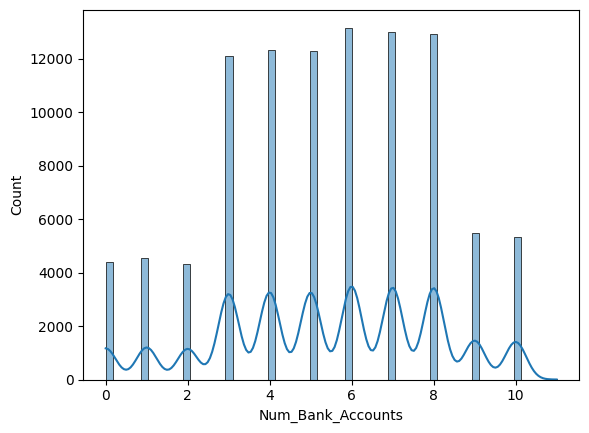

In [16]:
sns.histplot(df.Num_Bank_Accounts,kde=True)


In [17]:
print('with 0 :',df.Num_Bank_Accounts.skew())
print('without 0 :',df['Num_Bank_Accounts'][df['Num_Bank_Accounts']!=0].skew())

with 0 : -0.19001504208866626
without 0 : -0.03959654741657464


In [18]:
# since skewness without that '0' is lesser than with '0'
# we'll fill replace the '0' with the mean of (Num_Bank_Accounts!=0).

Num_Bank_Accounts_mean = df.Num_Bank_Accounts[df.Num_Bank_Accounts!=0].mean()
Num_Bank_Accounts_mean

np.float64(5.616919326658506)

In [19]:
# even though the mean valus is float type which dosent make sense for 'how much accouts customer have' 
# we can still use the float value to replace the '0' 
# as the model dosent care bout what makes sense in real world 
# so the actual float mean value will be better for the model.

df.Num_Bank_Accounts = df.Num_Bank_Accounts.replace(0,Num_Bank_Accounts_mean)

In [20]:
df.Num_Bank_Accounts[df.Num_Bank_Accounts == 0].sum()

np.float64(0.0)

In [21]:
num_cols_with_0

['Num_Bank_Accounts',
 'Num_Credit_Card',
 'Num_of_Loan',
 'Delay_from_due_date',
 'Num_of_Delayed_Payment',
 'Num_Credit_Inquiries',
 'Total_EMI_per_month',
 'Amount_invested_monthly']

In [22]:
# next Num_Credit_Card
# people might not have any credit card so its possible the value is 0
# yet we might check those values as only 14 values are 0

df[df.Num_Credit_Card == 0].T

,4716,4717,4718,4719,9278,9279,10588,10589,10590,10591,24980,24981,24982,24983
Month,5,6,7,8,7,8,5,6,7,8,5,6,7,8
Age,24.0,24.0,24.0,24.0,23.0,23.0,29.0,29.0,29.0,29.0,46.0,47.0,47.0,47.0
SSN,954978593.0,954978593.0,954978593.0,954978593.0,145676657.0,145676657.0,769911021.0,769911021.0,769911021.0,769911021.0,552023722.0,552023722.0,552023722.0,552023722.0
Occupation,Writer,Writer,Writer,Writer,Mechanic,Mechanic,Musician,Musician,Musician,Musician,Accountant,Accountant,Accountant,Accountant
Annual_Income,101912.13,101912.13,101912.13,101912.13,116721.18,116721.18,79548.32,79548.32,79548.32,79548.32,39296.5,39296.5,39296.5,39296.5
Monthly_Inhand_Salary,8503.6775,8503.6775,8503.6775,8503.6775,9552.765,9552.765,6355.026667,6355.026667,6355.026667,6355.026667,3261.708333,3261.708333,3261.708333,3261.708333
Num_Bank_Accounts,4.0,4.0,4.0,4.0,1.0,1.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
Num_Credit_Card,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Interest_Rate,4.0,4.0,4.0,4.0,12.0,12.0,3.0,3.0,3.0,3.0,1.0,1.0,1.0,1.0
Num_of_Loan,0.0,0.0,0.0,0.0,1.0,1.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0


In [23]:
df[['Changed_Credit_Limit','Credit_Utilization_Ratio','Num_Credit_Inquiries']].describe()


,Changed_Credit_Limit,Credit_Utilization_Ratio,Num_Credit_Inquiries
count,100000.000000,100000.000000,100000.000000
mean,10.470323,32.285173,5.798250
std,6.609481,5.116875,3.867826
min,0.500000,20.000000,0.000000
25%,5.380000,28.052567,3.000000
50%,9.400000,32.305784,5.000000
75%,14.850000,36.496663,8.000000
max,29.980000,50.000000,17.000000


In [24]:
# i guess if one has no credit cards .. then Changed_Credit_Limit, Credit_Utilization_Ratio, Num_Credit_Inquiries should most likely be 0 as well
# so may be that '0' in Num_Credit_Card is missing values
# and since its just 14 values .. we can drop those.

df1 = df[df.Num_Credit_Card !=0].copy()
df1.shape

(99986, 25)

In [25]:
df1.Num_Credit_Card[df1.Num_Credit_Card ==0].sum()

np.float64(0.0)

In [26]:
num_cols_with_0

['Num_Bank_Accounts',
 'Num_Credit_Card',
 'Num_of_Loan',
 'Delay_from_due_date',
 'Num_of_Delayed_Payment',
 'Num_Credit_Inquiries',
 'Total_EMI_per_month',
 'Amount_invested_monthly']

In [27]:
# next Num_of_Loan which has ~11k '0' values
# but some people will not get any loans, so its totaly possible.

# lets check some sample just in case

df1[['Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score']][df1.Num_of_Loan == 0].sample(10)

,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
82906,12.0,0.0,No Data,8.0,10.0,1.24,2.0,Good,663.25,32.444997,227.0,NM,0.000000,156.818476,Low_spent_Medium_value_payments,534.668195,Standard
5367,11.0,0.0,No Data,21.0,15.0,19.43,11.0,Standard,1001.74,26.553337,233.0,Yes,0.000000,79.746526,High_spent_Small_value_payments,514.741800,Standard
83040,10.0,0.0,No Data,14.0,5.0,0.78,2.0,Good,472.29,30.486859,302.0,No,0.000000,88.139442,High_spent_Small_value_payments,822.358058,Poor
32787,2.0,0.0,No Data,8.0,6.0,1.42,4.0,Good,1245.73,26.227960,383.0,No,0.000000,73.075349,Low_spent_Medium_value_payments,844.722566,Good
2991,4.0,0.0,No Data,5.0,5.0,1.05,3.0,Good,933.84,27.005230,335.0,No,0.000000,147.849944,High_spent_Small_value_payments,880.519719,Good
178,1.0,0.0,No Data,2.0,6.0,0.86,0.0,Good,76.23,42.070459,395.0,No,0.000000,172.032829,High_spent_Large_value_payments,955.309921,Good
26505,12.0,0.0,No Data,3.0,11.0,6.64,1.0,Good,921.03,34.655790,333.0,No,0.000000,70.788136,Low_spent_Medium_value_payments,408.325465,Standard
37889,5.0,0.0,No Data,18.0,9.0,3.19,5.0,Good,1089.19,34.904713,392.0,NM,0.000000,67.668153,Low_spent_Small_value_payments,264.709897,Poor
21101,1.0,0.0,No Data,7.0,20.0,3.96,6.0,Good,1198.09,40.728206,400.0,No,860.370892,49.722843,Low_spent_Medium_value_payments,481.939123,Good
30980,5.0,0.0,No Data,14.0,0.0,8.73,1.0,Good,830.07,41.046950,249.0,No,0.000000,86.931212,High_spent_Medium_value_payments,658.062150,Good


In [28]:
df1[(df1.Num_of_Loan == 0) & ((df1.Type_of_Loan != 'No Data') | (df1.Total_EMI_per_month != 0))].shape

(423, 25)

In [29]:
df1[(df1.Num_of_Loan == 0) & ((df1.Type_of_Loan != 'No Data'))].shape

(0, 25)

In [30]:
# so if a person has no loans then Type_of_Loan should be 'No Data' and Total_EMI_per_month should be 0 .. ig
# so lets look at whats going on

df1[['Num_of_Loan','Total_EMI_per_month']][(df1.Num_of_Loan == 0) & (df1.Total_EMI_per_month != 0)].sample(10)

,Num_of_Loan,Total_EMI_per_month
90740,0.0,160.846303
60021,0.0,209.155074
35131,0.0,696.214944
1174,0.0,160.585877
99519,0.0,1494.838012
81966,0.0,686.736257
1173,0.0,160.585877
50194,0.0,253.674265
15961,0.0,1102.977069
51855,0.0,1241.203549


In [31]:
df1[(df1.Num_of_Loan == 0) & (df1.Total_EMI_per_month != 0)].sample(10)

,Month,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
9382,7,30.0,512008324.0,Lawyer,177907.720,13078.430052,5.616919,6.0,6.0,0.0,...,Good,685.01,50.000000,373.0,No,1634.213281,145.138761,High_spent_Medium_value_payments,881.306347,Standard
10949,6,20.0,132807668.0,Entrepreneur,20785.005,1659.848359,4.000000,5.0,4.0,0.0,...,Good,125.84,38.231332,216.0,No,177.235391,20.793832,Low_spent_Small_value_payments,324.306507,Good
53535,8,31.0,921307278.0,Journalist,33726.600,2477.672444,6.000000,5.0,19.0,0.0,...,Standard,1251.27,31.781575,342.0,Yes,382.877556,60.174876,High_spent_Medium_value_payments,445.992035,Standard
90740,5,34.0,617774990.0,Developer,36539.180,3101.085363,2.000000,5.0,11.0,0.0,...,Good,15.03,41.548694,216.0,No,160.846303,23.940521,High_spent_Large_value_payments,505.434293,Good
35133,6,20.0,971495241.0,Musician,58225.780,4115.933389,5.000000,7.0,15.0,0.0,...,Standard,164.38,33.773802,302.0,No,696.214944,90.374373,Low_spent_Small_value_payments,268.147628,Good
30271,8,28.0,385631732.0,Journalist,12167.220,1114.617912,5.000000,7.0,15.0,0.0,...,Standard,124.66,36.395664,218.0,NM,97.317088,46.015888,Low_spent_Small_value_payments,267.403544,Good
29975,8,41.0,514084156.0,Journalist,17603.265,1324.945978,8.000000,6.0,4.0,0.0,...,Standard,836.66,41.792553,189.0,No,102.992772,20.634489,High_spent_Large_value_payments,362.159386,Good
81934,7,26.0,884856493.0,Engineer,83642.910,6148.311617,3.000000,5.0,6.0,0.0,...,Standard,793.04,35.634782,239.0,Yes,882.930883,52.921491,High_spent_Large_value_payments,890.202759,Good
99519,8,54.0,746796875.0,Lawyer,150131.680,11102.135322,5.000000,1.0,4.0,0.0,...,Good,1138.36,45.255807,383.0,No,1494.838012,122.041469,High_spent_Medium_value_payments,440.497523,Standard
30265,2,27.0,385631732.0,Journalist,12167.220,1114.617912,5.000000,7.0,15.0,0.0,...,Standard,124.66,33.582458,212.0,Yes,97.317088,46.015888,Low_spent_Small_value_payments,334.163300,Standard


In [32]:
df1.Total_EMI_per_month.describe()

count    99986.000000
mean       107.699181
std        132.272850
min          0.000000
25%         29.268886
50%         66.462304
75%        147.392573
max       1779.103254
Name: Total_EMI_per_month, dtype: float64

In [33]:
# so 423 people has no loans and yet has emi .. 
# so most probably they filled missing values in Num_of_Loan with '0' for these 423 rows
# so now we can take mean or median value for Num_of_Loan for these 432 rows and replace it for that '0'
# because then we can fill the Type_of_Loan also Total_EMI_per_month for the mean or median of Type_of_Loan wont be good

# so either we drop these rows 
# or replace all the values in Total_EMI_per_month for that 432 values with '0' 

#lets try keeping it and replacing it with '0' .

In [34]:
df2 = df1.copy()

In [35]:
df2.loc[(df2.Num_of_Loan == 0) & (df2.Total_EMI_per_month != 0),'Total_EMI_per_month'] = 0

In [36]:
df1[(df1.Num_of_Loan == 0) & (df1.Total_EMI_per_month != 0)].shape

(423, 25)

In [37]:
df2[(df2.Num_of_Loan == 0) & (df2.Total_EMI_per_month != 0)].shape

(0, 25)

In [38]:
df1 is df2

False

In [39]:
num_cols_with_0 

['Num_Bank_Accounts',
 'Num_Credit_Card',
 'Num_of_Loan',
 'Delay_from_due_date',
 'Num_of_Delayed_Payment',
 'Num_Credit_Inquiries',
 'Total_EMI_per_month',
 'Amount_invested_monthly']

In [40]:
# next Delay_from_due_date which has 1385 '0' values
# usually its totally make sense because a person will always try to pay the dept on time so '0' mean they didnt dely to pay
# but we should also check the Num_of_Delayed_Payment as well parallely 
# as only if you delay the pau]yment yooull have delayed no of days.

df2[(df2.Delay_from_due_date == 0) & (df2.Num_of_Delayed_Payment == 0)].shape 

(108, 25)

In [41]:
df2[['Num_Credit_Card',
       'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score']][((df2.Delay_from_due_date == 0) | (df2.Num_of_Delayed_Payment == 0)) &
    ~((df2.Delay_from_due_date == 0) & (df2.Num_of_Delayed_Payment == 0))].sample(10)

,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
73964,7.0,9.0,2.0,"Credit-Builder Loan, and Home Equity Loan",6.0,0.0,9.32,3.0,Good,344.42,40.818110,383.0,No,145.513639,126.919703,Low_spent_Medium_value_payments,428.198869,Standard
67672,4.0,12.0,4.0,"Mortgage Loan, Payday Loan, Credit-Builder Loa...",2.0,0.0,2.07,0.0,Good,284.52,29.784208,274.0,No,179.304812,59.477685,Low_spent_Medium_value_payments,255.121565,Good
23689,4.0,20.0,1.0,Auto Loan,0.0,13.0,2.43,4.0,Standard,791.78,25.113968,270.0,No,31.245931,40.184095,High_spent_Medium_value_payments,568.603840,Standard
46320,6.0,2.0,3.0,"Student Loan, Debt Consolidation Loan, and Deb...",19.0,0.0,2.88,0.0,Good,710.17,35.851965,271.0,No,310.159418,124.480531,High_spent_Large_value_payments,680.117936,Poor
38851,3.0,3.0,3.0,"Auto Loan, Credit-Builder Loan, and Not Specified",0.0,7.0,4.26,1.0,Good,707.24,34.038930,376.0,No,198.147110,70.360647,High_spent_Large_value_payments,847.518421,Standard
8110,2.0,4.0,0.0,No Data,2.0,0.0,6.39,5.0,Good,43.02,29.889700,368.0,No,0.000000,36.033385,High_spent_Small_value_payments,386.143826,Standard
37394,7.0,2.0,4.0,"Home Equity Loan, Debt Consolidation Loan, Hom...",7.0,0.0,9.34,1.0,Good,441.24,38.511588,384.0,NM,107.490080,70.198116,Low_spent_Large_value_payments,254.914780,Poor
78074,3.0,9.0,1.0,Mortgage Loan,5.0,0.0,7.02,3.0,Good,1483.39,41.144467,247.0,No,20.272735,79.101603,Low_spent_Large_value_payments,475.816698,Good
39498,2.0,5.0,0.0,No Data,10.0,0.0,8.63,5.0,Good,929.04,38.514239,357.0,No,0.000000,59.586475,Low_spent_Large_value_payments,303.091766,Good
64096,3.0,10.0,2.0,"Student Loan, and Debt Consolidation Loan",7.0,0.0,4.20,1.0,Good,1357.63,33.991788,211.0,No,71.716893,50.715769,High_spent_Small_value_payments,648.668338,Standard


In [42]:
df2[((df2.Delay_from_due_date == 0) | (df2.Num_of_Delayed_Payment == 0)) &
    ~((df2.Delay_from_due_date == 0) & (df2.Num_of_Delayed_Payment == 0))].shape

(3250, 25)

In [43]:
df2[((df2.Delay_from_due_date == 0) & (df2.Num_of_Delayed_Payment > 0)) &
    ~((df2.Delay_from_due_date == 0) & (df2.Num_of_Delayed_Payment == 0))].shape

(1277, 25)

In [44]:
df2[['Delay_from_due_date','Num_of_Delayed_Payment']][((df2.Delay_from_due_date == 0) & (df2.Num_of_Delayed_Payment > 0)) &
    ~((df2.Delay_from_due_date == 0) & (df2.Num_of_Delayed_Payment == 0))].sample(10)

,Delay_from_due_date,Num_of_Delayed_Payment
56884,0.0,5.0
19172,0.0,10.0
57141,0.0,5.0
10065,0.0,7.0
57085,0.0,2.0
92725,0.0,11.0
32494,0.0,4.0
69941,0.0,3.0
73277,0.0,6.0
4603,0.0,3.0


In [45]:
df2[((df2.Delay_from_due_date == 0) & (df2.Num_of_Delayed_Payment > 0)) | \
    ((df2.Delay_from_due_date == 0) & (df2.Num_of_Delayed_Payment == 0))].shape

(1385, 25)

In [46]:
# so ... if Num_of_Delayed_Payment is 0 then Delay_from_due_date should also be 0
# because if you didnt delay any payment then how can you have delayed days

# but may be we can keep the rows where Num_of_Delayed_Payment is >0 then Delay_from_due_date could be 0 
# because may be if they payed their payment within 24 hours from the due date , then may be it might have considered as 0 days 

# so well make all other 'dosent make sense' data into 0 .

In [47]:
df3 = df2.copy()

In [48]:
delay_ignore = ((df3.Delay_from_due_date == 0) & (df3.Num_of_Delayed_Payment > 0))

df3.loc[((df3.Num_of_Delayed_Payment == 0) | (df3.Delay_from_due_date == 0)) & ~delay_ignore , \
        ['Delay_from_due_date', 'Num_of_Delayed_Payment']] = 0

In [49]:
df3[(df3.Delay_from_due_date == 0) & (df3.Num_of_Delayed_Payment == 0)].shape

(2081, 25)

In [50]:
num_cols_with_0

['Num_Bank_Accounts',
 'Num_Credit_Card',
 'Num_of_Loan',
 'Delay_from_due_date',
 'Num_of_Delayed_Payment',
 'Num_Credit_Inquiries',
 'Total_EMI_per_month',
 'Amount_invested_monthly']

In [51]:
df.columns

Index(['Month', 'Age', 'SSN', 'Occupation', 'Annual_Income',
       'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card',
       'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [52]:
# next Num_Credit_Inquiries with 7190 zeros
# so here its possible that its 0 
# but we should check many other features to confirm it
# like .. num_of_loan, Num_Credit_Card, Changed_Credit_Limit, Credit_History_Age are important features to check with
# the above features have indirect relation with Num_Credit_Inquiries .. if they are more then the posibility of Num_Credit_Inquiries being 0 is soo less

In [53]:
df3[['Num_Credit_Card','Num_of_Loan','Changed_Credit_Limit','Credit_History_Age']][(df3.Num_Credit_Inquiries == 0)].describe()

#& (df3.Num_of_Loan == 0) & (df3.Num_Credit_Card == 0) & (df3.Changed_Credit_Limit == 0) & (df3.Credit_History_Age == 0)

,Num_Credit_Card,Num_of_Loan,Changed_Credit_Limit,Credit_History_Age
count,7190.00000,7190.000000,7190.000000,7190.00000
mean,4.64854,2.023088,7.303951,293.17580
std,1.63513,1.398595,4.309725,62.34714
min,1.00000,0.000000,0.500000,181.00000
25%,3.00000,1.000000,3.840000,240.00000
50%,5.00000,2.000000,7.140000,293.00000
75%,6.00000,3.000000,10.270000,349.00000
max,8.00000,4.000000,26.980000,402.00000


In [54]:
df3[['Num_Credit_Card','Num_of_Loan','Changed_Credit_Limit','Credit_History_Age','Num_Credit_Inquiries']].describe()

,Num_Credit_Card,Num_of_Loan,Changed_Credit_Limit,Credit_History_Age,Num_Credit_Inquiries
count,99986.000000,99986.000000,99986.000000,99986.000000,99986.000000
mean,5.534345,3.533035,10.470816,221.208499,5.798682
std,2.066206,2.446396,6.609693,99.680965,3.867921
min,1.000000,0.000000,0.500000,1.000000,0.000000
25%,4.000000,2.000000,5.380000,144.000000,3.000000
50%,5.000000,3.000000,9.400000,219.000000,5.000000
75%,7.000000,5.000000,14.850000,302.000000,8.000000
max,11.000000,9.000000,29.980000,404.000000,17.000000


In [55]:
df3[(df3.Num_Credit_Inquiries == 0) & ((df3['Num_of_Loan'] > 0) | (df3['Num_Credit_Card'] > 1) | \
    (df3['Changed_Credit_Limit'] > 0) | (df3['Credit_History_Age'] > 24))].shape

(7190, 25)

In [56]:
# so what happenes here is ..
# they might give credit card for the customer without inquiry for the 1st time .. thats why Num_Credit_Card > 1
# they mostly wont give loan without inquiry so Num_of_Loan > 0
# they wont just let you change your credit limit without knowing you are reliable .. so Changed_Credit_Limit > 0
# and  Credit_History_Age is in months ... usualy a acc cant be unnoticed (not inquired) for a long time .. 
    # so may be if if you have the acc for 1 or 2 years (12 to 24 months) they might not inquire it so Credit_History_Age > 24 .

In [57]:
df3[(df3.Num_Credit_Inquiries == 0) & (df3['Num_of_Loan'] > 0)].shape

(5842, 25)

In [58]:
df3[(df3.Num_Credit_Inquiries == 0) & (df3['Num_Credit_Card'] > 1)].shape

(6901, 25)

In [59]:
df3[(df3.Num_Credit_Inquiries == 0) & (df3['Changed_Credit_Limit'] > 0)].shape

(7190, 25)

In [60]:
df3[(df3.Num_Credit_Inquiries == 0) & (df3['Credit_History_Age'] > 24)].shape

(7190, 25)

In [61]:
df3[df3.Num_Credit_Inquiries == 0].shape

(7190, 25)

In [62]:
# but we can see that .. the individual feature amoung those 4 features with our condition itself covers all those 7190 rows .
# so we should treat all those 7190 vaues as missing values.

# dropping 7190 rows is 7.2% of the data
# so may be we'll just replace it with mean or median

In [63]:
print('with 0 :',df.Num_Credit_Inquiries.skew())
print('without 0 :',df['Num_Credit_Inquiries'][df['Num_Credit_Inquiries']!=0].skew())

with 0 : 0.4068253621472536
without 0 : 0.4618785027267072


In [64]:
# <0.5 means median is better , >0.5 means mean is better
# the closer it is to 0 the better the mean is
# so we take mean for Num_Credit_Inquiries including the '0' values 

Num_Credit_Inquiries_mean = df3.Num_Credit_Inquiries.mean()
Num_Credit_Inquiries_mean

np.float64(5.798681815454164)

In [65]:
df3.Num_Credit_Inquiries = df3.Num_Credit_Inquiries.replace(0,Num_Credit_Inquiries_mean)

In [66]:
df3[df3.Num_Credit_Inquiries == Num_Credit_Inquiries_mean].shape

(7190, 25)

In [67]:
num_cols_with_0

['Num_Bank_Accounts',
 'Num_Credit_Card',
 'Num_of_Loan',
 'Delay_from_due_date',
 'Num_of_Delayed_Payment',
 'Num_Credit_Inquiries',
 'Total_EMI_per_month',
 'Amount_invested_monthly']

In [68]:
df3[df3.Total_EMI_per_month == 0].shape

(11404, 25)

In [69]:
df3[df3.Num_of_Loan == 0].shape

(11404, 25)

In [70]:
# since we already made all non zero values of total_emi_per_month to 0 where num_of_loan is 0
# and we can see that shape of both of them when 0 is same 
# so we can say that all the 0 in total_emi_per_month is already taken care of

In [71]:
num_cols_with_0

['Num_Bank_Accounts',
 'Num_Credit_Card',
 'Num_of_Loan',
 'Delay_from_due_date',
 'Num_of_Delayed_Payment',
 'Num_Credit_Inquiries',
 'Total_EMI_per_month',
 'Amount_invested_monthly']

In [72]:
df3[df3.Amount_invested_monthly == 0].shape

(1920, 25)

In [73]:
# next is Amount_invested_monthly
# investing isint that necessary for everyone .. so its possible to be 0
# so no other feature actually have any relation with this feature
# this is more of an independent feature also zeros are completely valid here
# so we can keep it as it is

In [74]:
df3.Amount_invested_monthly.describe()

count    99986.000000
mean        55.098971
std         39.007795
min          0.000000
25%         27.954834
50%         45.156261
75%         71.288876
max        434.191089
Name: Amount_invested_monthly, dtype: float64

In [75]:
# so now that we covered all the zeros/missing_values in the numeric clmn of the dataset .. lets move on to next

In [76]:
# now may be lets deal with obj columns .. and transform them into numeric columns

In [77]:
obj_cols = df3.select_dtypes(include=['object']).columns
obj_cols

Index(['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount',
       'Payment_Behaviour', 'Credit_Score'],
      dtype='object')

In [78]:
# may be lets 1st see how much umique values are there in each obj column

df3[obj_cols].nunique()

Occupation                 15
Type_of_Loan             6261
Credit_Mix                  3
Payment_of_Min_Amount       3
Payment_Behaviour           6
Credit_Score                3
dtype: int64

In [79]:
print(df3[obj_cols].shape)
print(df3[float_int_cols].shape)

(99986, 6)
(99986, 19)


In [80]:
# 19 + 6 = 25 ... no columns are left .. so lets continue

In [81]:
df3[obj_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 99986 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Occupation             99986 non-null  object
 1   Type_of_Loan           99986 non-null  object
 2   Credit_Mix             99986 non-null  object
 3   Payment_of_Min_Amount  99986 non-null  object
 4   Payment_Behaviour      99986 non-null  object
 5   Credit_Score           99986 non-null  object
dtypes: object(6)
memory usage: 5.3+ MB


In [82]:
# Type_of_Loan have 6k unique values ... so look into that fetaure 1st

df3.Type_of_Loan.sample(10)

43975    Mortgage Loan, Auto Loan, Debt Consolidation L...
73315                              Debt Consolidation Loan
24324                      Home Equity Loan, and Auto Loan
46457                                        Mortgage Loan
23222    Credit-Builder Loan, Student Loan, Student Loa...
36270            Debt Consolidation Loan, and Student Loan
84452    Mortgage Loan, Credit-Builder Loan, Auto Loan,...
23114    Debt Consolidation Loan, Student Loan, Payday ...
70791              Auto Loan, Auto Loan, and Not Specified
5838                                           Payday Loan
Name: Type_of_Loan, dtype: object

In [83]:
df3[df3.Type_of_Loan == 'No Data'].shape

(11404, 25)

In [84]:
df3[(df3.Num_of_Loan == 0) & (df3.Type_of_Loan == 'No Data')].shape

(11404, 25)

In [85]:
# so this feature kinda feels complex so lets deal with it later

# as other obj clmns have less unique values we can see what they are 
# and see if they are ordinal or nominal



In [86]:
obj_cols_2 = ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour', 'Credit_Score']
for col in obj_cols_2:
    print(col, df3[col].unique(), '\n')

Occupation ['Scientist' 'Teacher' 'Engineer' 'Entrepreneur' 'Developer' 'Lawyer'
 'Media_Manager' 'Doctor' 'Journalist' 'Manager' 'Accountant' 'Musician'
 'Mechanic' 'Writer' 'Architect'] 

Credit_Mix ['Good' 'Standard' 'Bad'] 

Payment_of_Min_Amount ['No' 'NM' 'Yes'] 

Payment_Behaviour ['High_spent_Small_value_payments' 'Low_spent_Large_value_payments'
 'Low_spent_Medium_value_payments' 'Low_spent_Small_value_payments'
 'High_spent_Medium_value_payments' 'High_spent_Large_value_payments'] 

Credit_Score ['Good' 'Standard' 'Poor'] 



In [87]:
# so Credit_Mix, Payment_of_Min_Amount, Payment_Behaviour, Credit_Score are ordinal features
# and Occupation is nominal feature

# so lets deal with ordinal features 1st

In [88]:
df4 = df3.copy()

In [89]:
# 1st Credit_Mix
df4['Credit_Mix_num'] = df4.Credit_Mix.map({'Bad':0,'Standard':1,'Good':2})

In [214]:
df.Credit_Score.unique()

array(['Good', 'Standard', 'Poor'], dtype=object)

In [90]:
df4[['Credit_Mix_num','Credit_Mix']].value_counts()

Credit_Mix_num  Credit_Mix
1               Standard      45848
2               Good          30370
0               Bad           23768
Name: count, dtype: int64

In [91]:
# next Payment_of_Min_Amount
df4.Payment_of_Min_Amount.unique()

array(['No', 'NM', 'Yes'], dtype=object)

In [92]:
df4['Payment_of_Min_Amount_num'] = df4.Payment_of_Min_Amount.map({'No':0,'NM':1,'Yes':2})
df4[['Payment_of_Min_Amount_num','Payment_of_Min_Amount']].value_counts()

Payment_of_Min_Amount_num  Payment_of_Min_Amount
2                          Yes                      52326
0                          No                       35655
1                          NM                       12005
Name: count, dtype: int64

In [93]:
# next Payment_Behaviour
df4.Payment_Behaviour.unique()

array(['High_spent_Small_value_payments',
       'Low_spent_Large_value_payments',
       'Low_spent_Medium_value_payments',
       'Low_spent_Small_value_payments',
       'High_spent_Medium_value_payments',
       'High_spent_Large_value_payments'], dtype=object)

In [94]:
df4['Payment_Behaviour_num'] = df4.Payment_Behaviour.map({'High_spent_Small_value_payments':0,
                                                          'Low_spent_Small_value_payments':1,
                                                          'High_spent_Medium_value_payments':2,
                                                          'Low_spent_Medium_value_payments':3,
                                                          'High_spent_Large_value_payments':4,
                                                          'Low_spent_Large_value_payments':5})
df4[['Payment_Behaviour_num','Payment_Behaviour']].value_counts()


Payment_Behaviour_num  Payment_Behaviour               
1                      Low_spent_Small_value_payments      28615
2                      High_spent_Medium_value_payments    19735
4                      High_spent_Large_value_payments     14724
3                      Low_spent_Medium_value_payments     14396
0                      High_spent_Small_value_payments     11762
5                      Low_spent_Large_value_payments      10754
Name: count, dtype: int64

In [95]:
# next Credit_Score
df4.Credit_Score.unique()

array(['Good', 'Standard', 'Poor'], dtype=object)

In [96]:
df4['Credit_Score_num'] = df4.Credit_Score.map({'Poor':0,'Standard':1,'Good':2})
df4[['Credit_Score_num','Credit_Score']].value_counts()

Credit_Score_num  Credit_Score
1                 Standard        53171
0                 Poor            28998
2                 Good            17817
Name: count, dtype: int64

In [97]:
df4.sample(5)

,Month,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,...,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Credit_Mix_num,Payment_of_Min_Amount_num,Payment_Behaviour_num,Credit_Score_num
77120,1,44.0,998304976.0,Mechanic,58468.08,4592.340,10.0,9.0,28.0,5.0,...,Yes,169.465156,38.241835,Low_spent_Large_value_payments,194.877782,Poor,1,2,5,0
35519,8,29.0,353396535.0,Scientist,44219.46,3855.955,6.0,7.0,12.0,7.0,...,NM,206.321039,48.887873,High_spent_Medium_value_payments,339.513718,Poor,1,1,2,0
49217,2,21.0,813689184.0,Architect,25433.40,1949.450,4.0,4.0,16.0,0.0,...,No,0.000000,28.955112,Low_spent_Small_value_payments,338.267814,Standard,1,0,1,1
79088,1,19.0,452111523.0,Teacher,16868.34,1570.695,10.0,7.0,22.0,8.0,...,Yes,101.505716,20.538954,Low_spent_Small_value_payments,223.458806,Poor,0,2,1,0
60384,1,36.0,806075871.0,Entrepreneur,43790.40,3845.200,8.0,6.0,31.0,8.0,...,Yes,221.167647,80.220233,High_spent_Small_value_payments,171.513832,Standard,0,2,0,1


In [98]:
# next to deal with the nominal feature 'Occupation'
# we can use one hot encoding 

# im using pandas get_dummies for one hot encoding
df5 = pd.get_dummies(df4, columns=['Occupation'], drop_first=True)

In [99]:
df5.columns

Index(['Month', 'Age', 'SSN', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
       'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix',
       'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score', 'Credit_Mix_num', 'Payment_of_Min_Amount_num',
       'Payment_Behaviour_num', 'Credit_Score_num', 'Occupation_Architect',
       'Occupation_Developer', 'Occupation_Doctor', 'Occupation_Engineer',
       'Occupation_Entrepreneur', 'Occupation_Journalist', 'Occupation_Lawyer',
       'Occupation_Manager', 'Occupation_Mechanic', 'Occupation_Media_Manager',
       'Occupation_Musician', 'Occupation_Scientist', 'Occupation_Teacher',
       'Occupation_Writer'],
      dtype='obj

In [100]:
# now lets deal with Type_of_Loan
# we gonna use multi hot encoding for this feature
# so we gonne split the values by ',' and then create new columns for each unique value

# before that we need to clean the values a bit
# like removing extra spaces and converting to lowercase etc ..

In [101]:
pd.set_option('display.max_colwidth', None)

In [102]:
df5.Type_of_Loan.sample(5)

80415            Credit-Builder Loan, Auto Loan, Personal Loan, Student Loan, Not Specified, Student Loan, and Home Equity Loan
263                                                                                              Mortgage Loan, and Payday Loan
2116                                                                     Student Loan, Debt Consolidation Loan, and Payday Loan
73288    Debt Consolidation Loan, Credit-Builder Loan, Debt Consolidation Loan, Student Loan, Payday Loan, and Home Equity Loan
18017                                                                                                                   No Data
Name: Type_of_Loan, dtype: object

In [103]:
# from the above sample we can see that each rows might have 2 or more loans of same type 
# like 'Student Loan, Student Loan, Personal Loan, and Auto Loan' 
# so using just multi hot encoding wont capture the count of each type of loan , it just tells if its present or not

# BUT!! we still gonna use multi hot encoding
# beacause we have num_of_loan feature which tells us how many loans the customer have
# and even though it wont tell us the count of each type of loan ..
# it still makes the model lighter .. and generalizes better

# we can use ' count-based encoding' but thatll make the model slightly heavier and might overfit a bit

In [104]:
df5['Type_of_Loan_clean'] = (df5['Type_of_Loan']
                             .str.lower()
                             .str.replace(r'\s*,?\s*and\s*,?\s*', ',', regex=True)
                             .str.replace(r'\s*,\s*', ',', regex=True)
                             .str.strip())

In [105]:
df5.Type_of_Loan_clean.sample(5)

4960     student loan,student loan,home equity loan,student loan,payday loan
5531                                 credit-builder loan,credit-builder loan
75531                  credit-builder loan,credit-builder loan,mortgage loan
21479                                                    credit-builder loan
23679                                                  payday loan,auto loan
Name: Type_of_Loan_clean, dtype: object

In [106]:
df5.Type_of_Loan_clean = (df5.Type_of_Loan_clean
                          .str.replace(' ', '_')
                          .str.replace('-', '_'))

In [107]:
df5['Type_of_Loan_clean'].sample(10)

32060    mortgage_loan,debt_consolidation_loan,not_specified,not_specified,credit_builder_loan,home_equity_loan,mortgage_loan
85732                                                                         personal_loan,credit_builder_loan,not_specified
82453                                                                                                                 no_data
50480                                          debt_consolidation_loan,debt_consolidation_loan,home_equity_loan,personal_loan
90907                                     student_loan,auto_loan,not_specified,mortgage_loan,credit_builder_loan,student_loan
16219                      payday_loan,personal_loan,credit_builder_loan,student_loan,credit_builder_loan,credit_builder_loan
36135                                                        debt_consolidation_loan,not_specified,home_equity_loan,auto_loan
8380                                                                                                payday_loan,not_sp

In [108]:
loan_names = df5['Type_of_Loan_clean'].str.split(',').explode().unique()
loan_names 

array(['auto_loan', 'credit_builder_loan', 'personal_loan',
       'home_equity_loan', 'not_specified', 'no_data', 'mortgage_loan',
       'student_loan', 'debt_consolidation_loan', 'payday_loan'],
      dtype=object)

In [109]:
loan_doc_freq = df5.Type_of_Loan_clean.str.get_dummies(sep=',').astype(bool).sum()
loan_doc_freq

auto_loan                  30560
credit_builder_loan        31728
debt_consolidation_loan    31032
home_equity_loan           31396
mortgage_loan              31360
no_data                    11404
not_specified              31676
payday_loan                31938
personal_loan              31100
student_loan               31040
dtype: int64

In [110]:
# so here we see that there's 'no_data' and 'not_specified' 
# no_data means num_of_loan is 0
# not_specified means probably missing value was replaced with this ..
# we cant just take take mode of that and replace it with that ... since all have alomst equal counts .. aroumd 3k
# so itll only make one type as 6k counts ..
# also if its missing .. we cant just fill it with some random type ... this might affect the credit score

# if the 'not_specified' count was low .. like less than 1% we might combain not_specified and no_data as one .. 
# because both kinda seems similar ... and combaining will alos reduce dimension ... 
# if low count for not_specified .. it also makes that clmn sparse .. 

# so its better to leave that type .. ie: not_specified as it is 
# the model will learn some usefull pattern out of it as well

In [111]:
loan_dummies = df5['Type_of_Loan_clean'].str.get_dummies(sep=',')
loan_dummies

,auto_loan,credit_builder_loan,debt_consolidation_loan,home_equity_loan,mortgage_loan,no_data,not_specified,payday_loan,personal_loan,student_loan
0,1,1,0,1,0,0,0,0,1,0
1,1,1,0,1,0,0,0,0,1,0
2,1,1,0,1,0,0,0,0,1,0
3,1,1,0,1,0,0,0,0,1,0
4,1,1,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
99995,1,0,0,0,0,0,0,0,0,1
99996,1,0,0,0,0,0,0,0,0,1
99997,1,0,0,0,0,0,0,0,0,1
99998,1,0,0,0,0,0,0,0,0,1


In [112]:
df6 = pd.concat([df5, loan_dummies], axis=1)

In [113]:
df6.columns

Index(['Month', 'Age', 'SSN', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
       'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix',
       'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score', 'Credit_Mix_num', 'Payment_of_Min_Amount_num',
       'Payment_Behaviour_num', 'Credit_Score_num', 'Occupation_Architect',
       'Occupation_Developer', 'Occupation_Doctor', 'Occupation_Engineer',
       'Occupation_Entrepreneur', 'Occupation_Journalist', 'Occupation_Lawyer',
       'Occupation_Manager', 'Occupation_Mechanic', 'Occupation_Media_Manager',
       'Occupation_Musician', 'Occupation_Scientist', 'Occupation_Teacher',
       'Occupation_Writer', 'Type_of_Loan_cle

In [114]:
df6.shape

(99986, 53)

In [115]:
df6.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99986 entries, 0 to 99999
Data columns (total 53 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Month                      99986 non-null  int64  
 1   Age                        99986 non-null  float64
 2   SSN                        99986 non-null  float64
 3   Annual_Income              99986 non-null  float64
 4   Monthly_Inhand_Salary      99986 non-null  float64
 5   Num_Bank_Accounts          99986 non-null  float64
 6   Num_Credit_Card            99986 non-null  float64
 7   Interest_Rate              99986 non-null  float64
 8   Num_of_Loan                99986 non-null  float64
 9   Type_of_Loan               99986 non-null  object 
 10  Delay_from_due_date        99986 non-null  float64
 11  Num_of_Delayed_Payment     99986 non-null  float64
 12  Changed_Credit_Limit       99986 non-null  float64
 13  Num_Credit_Inquiries       99986 non-null  float64


In [116]:
df6.head(2).T

,0,1
Month,1,2
Age,23.0,23.0
SSN,821000265.0,821000265.0
Annual_Income,19114.12,19114.12
Monthly_Inhand_Salary,1824.843333,1824.843333
Num_Bank_Accounts,3.0,3.0
Num_Credit_Card,4.0,4.0
Interest_Rate,3.0,3.0
Num_of_Loan,4.0,4.0
Type_of_Loan,"Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan","Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan"


In [117]:
bool_cols = df6.select_dtypes(include=['bool']).columns
bool_cols

Index(['Occupation_Architect', 'Occupation_Developer', 'Occupation_Doctor',
       'Occupation_Engineer', 'Occupation_Entrepreneur',
       'Occupation_Journalist', 'Occupation_Lawyer', 'Occupation_Manager',
       'Occupation_Mechanic', 'Occupation_Media_Manager',
       'Occupation_Musician', 'Occupation_Scientist', 'Occupation_Teacher',
       'Occupation_Writer'],
      dtype='object')

In [118]:
df6[bool_cols] = df6[bool_cols].astype(int)

In [119]:
df6[bool_cols].head()

,Occupation_Architect,Occupation_Developer,Occupation_Doctor,Occupation_Engineer,Occupation_Entrepreneur,Occupation_Journalist,Occupation_Lawyer,Occupation_Manager,Occupation_Mechanic,Occupation_Media_Manager,Occupation_Musician,Occupation_Scientist,Occupation_Teacher,Occupation_Writer
0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [120]:
df6.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99986 entries, 0 to 99999
Data columns (total 53 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Month                      99986 non-null  int64  
 1   Age                        99986 non-null  float64
 2   SSN                        99986 non-null  float64
 3   Annual_Income              99986 non-null  float64
 4   Monthly_Inhand_Salary      99986 non-null  float64
 5   Num_Bank_Accounts          99986 non-null  float64
 6   Num_Credit_Card            99986 non-null  float64
 7   Interest_Rate              99986 non-null  float64
 8   Num_of_Loan                99986 non-null  float64
 9   Type_of_Loan               99986 non-null  object 
 10  Delay_from_due_date        99986 non-null  float64
 11  Num_of_Delayed_Payment     99986 non-null  float64
 12  Changed_Credit_Limit       99986 non-null  float64
 13  Num_Credit_Inquiries       99986 non-null  float64


In [121]:
df7 = df6.drop(['Type_of_Loan','Type_of_Loan_clean','Credit_Mix','Payment_of_Min_Amount','Payment_Behaviour','Credit_Score'],axis='columns')
df7.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99986 entries, 0 to 99999
Data columns (total 47 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Month                      99986 non-null  int64  
 1   Age                        99986 non-null  float64
 2   SSN                        99986 non-null  float64
 3   Annual_Income              99986 non-null  float64
 4   Monthly_Inhand_Salary      99986 non-null  float64
 5   Num_Bank_Accounts          99986 non-null  float64
 6   Num_Credit_Card            99986 non-null  float64
 7   Interest_Rate              99986 non-null  float64
 8   Num_of_Loan                99986 non-null  float64
 9   Delay_from_due_date        99986 non-null  float64
 10  Num_of_Delayed_Payment     99986 non-null  float64
 11  Changed_Credit_Limit       99986 non-null  float64
 12  Num_Credit_Inquiries       99986 non-null  float64
 13  Outstanding_Debt           99986 non-null  float64


In [122]:
# df7.to_csv('preprocessed_dataset.csv', index=False)

In [123]:
# now that we have preprocessed the data .. we can see the correlation btw the features and the target variable 'Credit_Score_num'
# and decide which features to keep or drop based on that

In [124]:
float_int_cols

Index(['Month', 'Age', 'SSN', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly',
       'Monthly_Balance'],
      dtype='object')

In [125]:
target = 'Credit_Score_num'
correlation = df7[['Month', 'Age', 'SSN', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly',
       'Monthly_Balance','Credit_Score_num']].corr()[target].sort_values(ascending=False)

<Axes: >

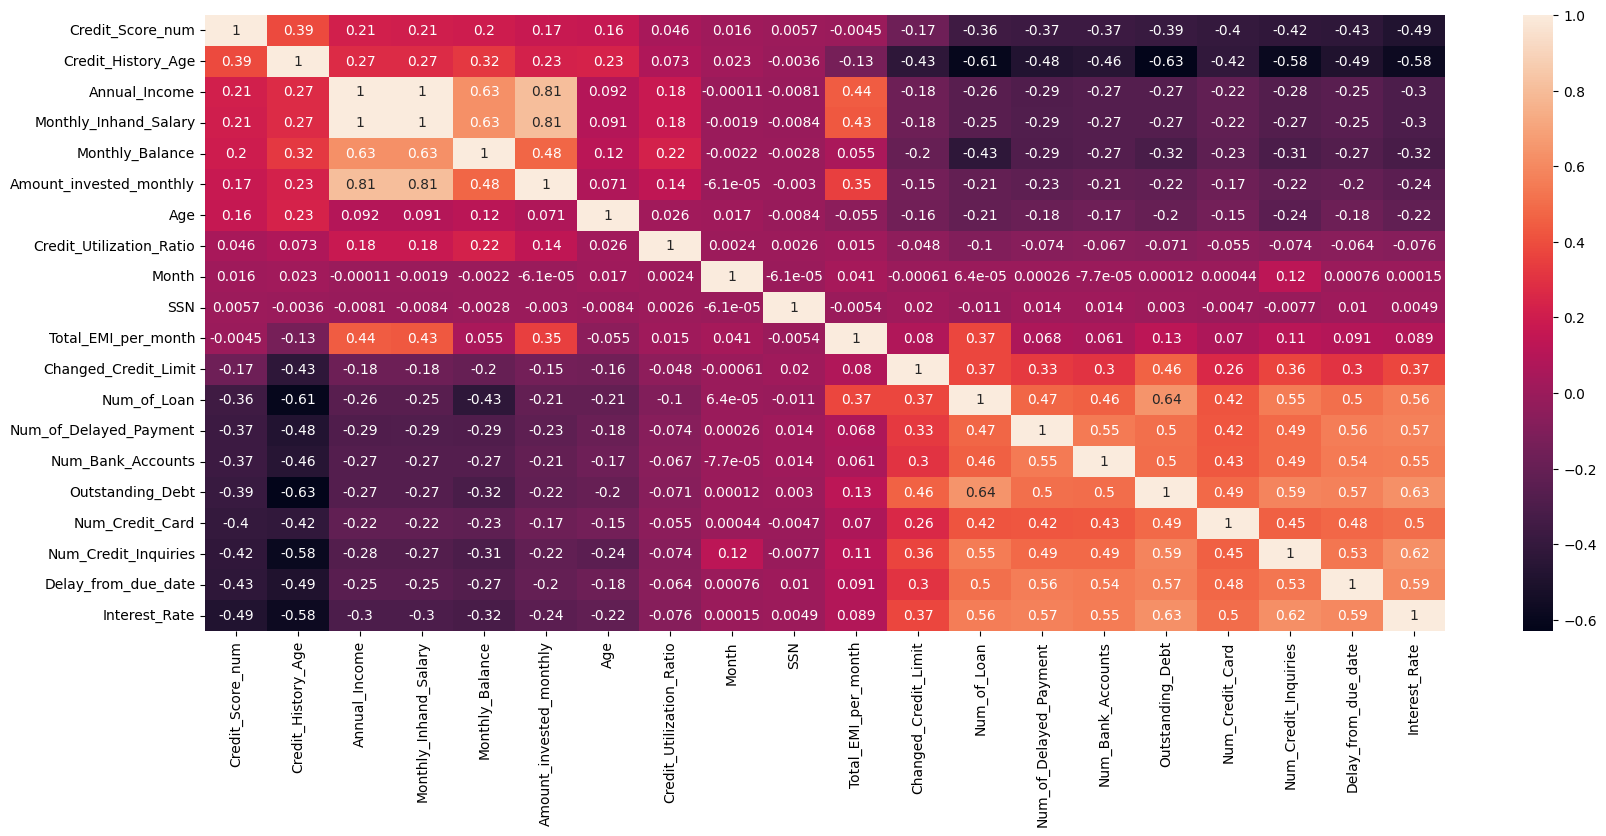

In [126]:
plt.figure(figsize=(20,8))
sns.heatmap(df7[correlation.index].corr(),annot=True)

In [127]:
# Monthly_Inhand_Salary is higlhy correlated with 3 features and amoung them one even has perfect correlation '1' 
# so we can drop Monthly_Inhand_Salary

df8 = df7.drop('Monthly_Inhand_Salary', axis='columns')
df8.columns.shape

(46,)

In [128]:
df7.shape

(99986, 47)

In [129]:
# Credit_History_Age and Outstanding_Debt both have a good corr with target 
# but also the have more than 0.5 corr with other 4 to 5 features as well 
# alsooo the corr btw each of them is -0.63 as well
# this might be redundant for the model

# buut one is possitive corr and other is negative corr
# both have different meaning as well .. dosent necessarily have same information

# so we can keep both of them for now

In [130]:
# SSN is Social Security Number
# which is just like name or id
# i should have dropped it at the bigining itself
# tthe very low corr of it with target and other features also confirms that

df8 = df8.drop('SSN', axis='columns')
df8.shape

(99986, 45)

In [131]:
# next Month feature has only like 1% corr with target and not so good corr with any other feature aswell
# also .. if its a time-sreries data .. where features are based on time .. then month feature will be an improtant feature
# but here its not a time-series data .. so month feature is not that improtant
# like .. our target credit score is based on many other features.. and those features are based of their monthly eranings most likely
# and almost all people have same earnings(salary) each month .. so this 'Month' feature wont do much in this model
# so well drop it

df8 = df8.drop('Month', axis='columns')
df8.shape

(99986, 44)

In [132]:
# other 2 features Credit_Utilization_Ratio and Total_EMI_per_month which even though it has less than 0.06 corr with target
# it still has good corr with 4 to 5 other features 
# and also both of these features have unique meaning and importance in real world scenario which might help the model capture some patterns
# so we can keep both of them for now

In [133]:
# we jsut looked at corr of the numerics cols of the original df
# so now next we can look corr of obj cols also with target (obj cols we transformed into numerics)

In [134]:
# 1st lets see Credit_Mix_num , Payment_of_Min_Amount_num , Payment_Behaviour_num (ordinal cols) as these are not one hot encoded so less columns to see

<Axes: >

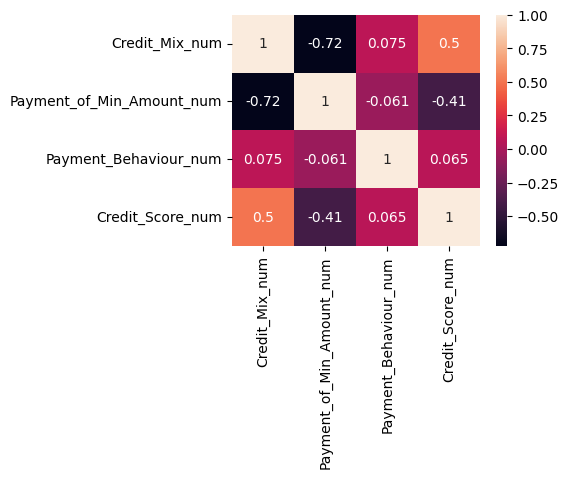

In [135]:
plt.figure(figsize=(4,3))
sns.heatmap(df8[['Credit_Mix_num', 'Payment_of_Min_Amount_num', 'Payment_Behaviour_num', 'Credit_Score_num']].corr(), annot=True)

In [136]:
# the corr seems lil higer than usual with 'Credit_Mix_num', 'Payment_of_Min_Amount_num' but well just keep it for now
# but payment_behaviour_num have very low corr with target and btw others

# so before deciding anything .. lets see its corr all other clmns 

<Axes: >

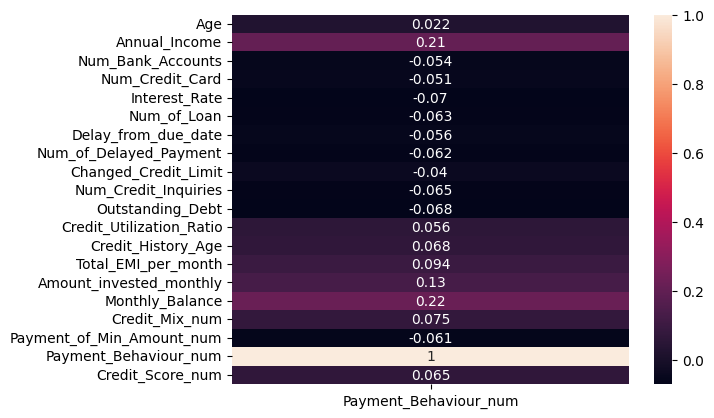

In [137]:
sns.heatmap(df8[[ 'Age','Annual_Income',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly',
       'Monthly_Balance','Credit_Mix_num', 'Payment_of_Min_Amount_num', 
       'Payment_Behaviour_num','Credit_Score_num']].corr()[['Payment_Behaviour_num']], annot=True)

<Axes: >

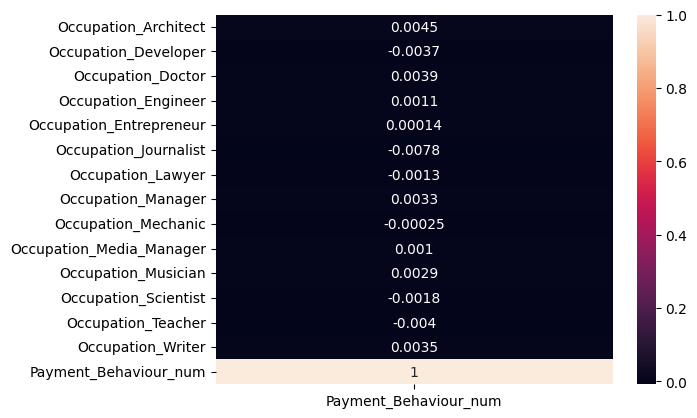

In [138]:
sns.heatmap(df8[['Occupation_Architect',
       'Occupation_Developer', 'Occupation_Doctor', 'Occupation_Engineer',
       'Occupation_Entrepreneur', 'Occupation_Journalist', 'Occupation_Lawyer',
       'Occupation_Manager', 'Occupation_Mechanic', 'Occupation_Media_Manager',
       'Occupation_Musician', 'Occupation_Scientist', 'Occupation_Teacher',
       'Occupation_Writer','Payment_Behaviour_num']].corr()[['Payment_Behaviour_num']], annot=True)

<Axes: >

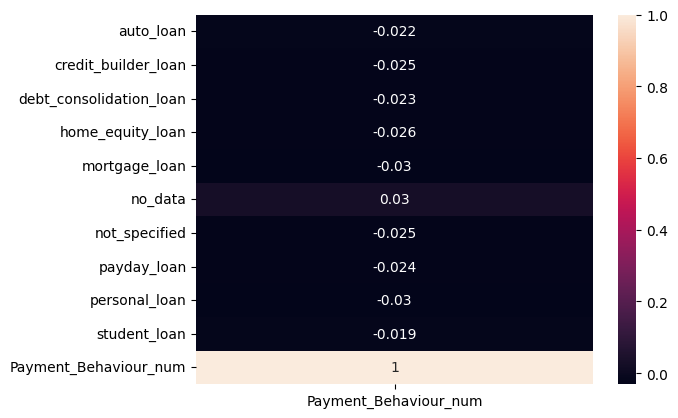

In [139]:
sns.heatmap(df8[['auto_loan', 'credit_builder_loan',
       'debt_consolidation_loan', 'home_equity_loan', 'mortgage_loan',
       'no_data', 'not_specified', 'payday_loan', 'personal_loan',
       'student_loan','Payment_Behaviour_num']].corr()[['Payment_Behaviour_num']], annot=True)

In [140]:
# only around 3 features have around 0.1 to 0.2 corr with Payment_Behaviour_num
# all others have less than 0.06 corr with Payment_Behaviour_num
# more importantly .. Payment_Behaviour_num have very low corr with target as well
# so we can drop it

df8 = df8.drop('Payment_Behaviour_num', axis='columns')
df8.shape

(99986, 43)

<Axes: >

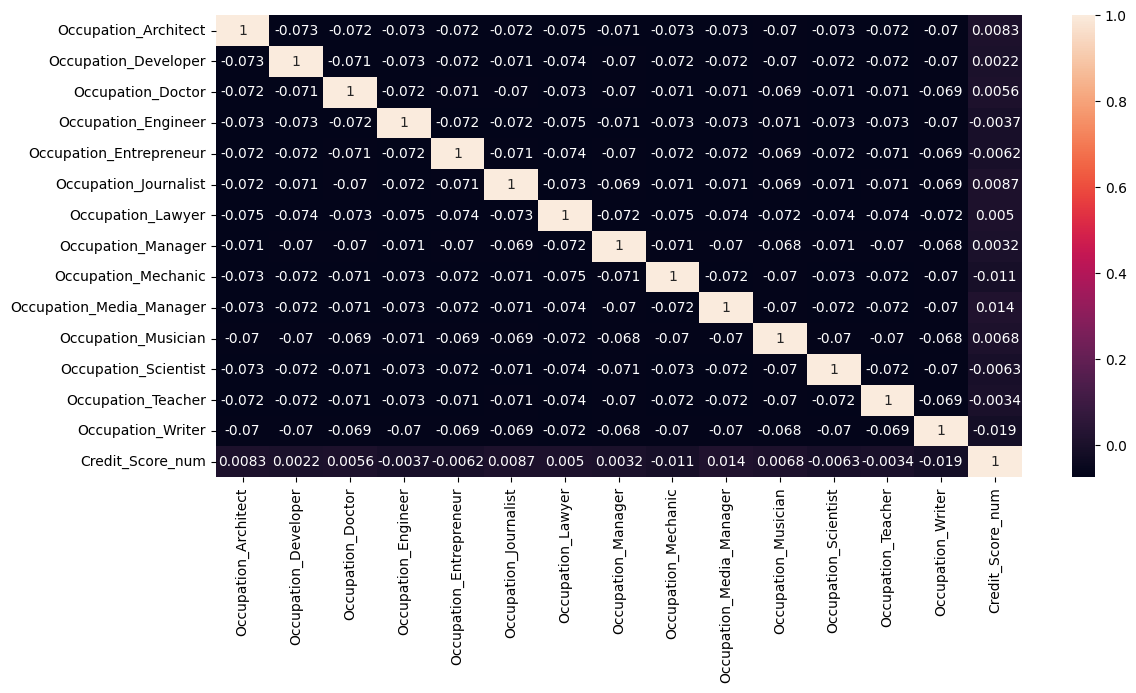

In [141]:
# now lets see the corr of the nominal features we created earlier
# in that 1st lets Occupation which we done ohe .. and has 14 cols

plt.figure(figsize=(13,6))
sns.heatmap(df8[[ 'Occupation_Architect',
       'Occupation_Developer', 'Occupation_Doctor', 'Occupation_Engineer',
       'Occupation_Entrepreneur', 'Occupation_Journalist', 'Occupation_Lawyer',
       'Occupation_Manager', 'Occupation_Mechanic', 'Occupation_Media_Manager',
       'Occupation_Musician', 'Occupation_Scientist', 'Occupation_Teacher',
       'Occupation_Writer','Credit_Score_num']].corr(), annot=True)

In [142]:
# the corr is less ... just as expected 
# because its a single clmn thats been divided into 14 .. by ohe
# also its just a boolen features
# and is very sparse ... ( with mostly 0 as value in every clmn)
# so its fine 

In [143]:
# annnnd ... apparently ... correlation only measures the LINEAR relationship btw features
# so there'll be some non-linear relation going behind

# and also ... its the same for the previous feature that we dropped as well
# ie : Payment_Behaviour_num 
# so may be we can re-add that feature again .. cos it might have some non-linear relation 

In [144]:
df9 = pd.concat([df8,df7.Payment_Behaviour_num],axis=1)

In [145]:
df9.columns.shape

(44,)

In [146]:
df9.columns

Index(['Age', 'Annual_Income', 'Num_Bank_Accounts', 'Num_Credit_Card',
       'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly',
       'Monthly_Balance', 'Credit_Mix_num', 'Payment_of_Min_Amount_num',
       'Credit_Score_num', 'Occupation_Architect', 'Occupation_Developer',
       'Occupation_Doctor', 'Occupation_Engineer', 'Occupation_Entrepreneur',
       'Occupation_Journalist', 'Occupation_Lawyer', 'Occupation_Manager',
       'Occupation_Mechanic', 'Occupation_Media_Manager',
       'Occupation_Musician', 'Occupation_Scientist', 'Occupation_Teacher',
       'Occupation_Writer', 'auto_loan', 'credit_builder_loan',
       'debt_consolidation_loan', 'home_equity_loan', 'mortgage_loan',
       'no_data', 'not_specified', 'payday_loan', 'personal_loan',
       'student

<Axes: >

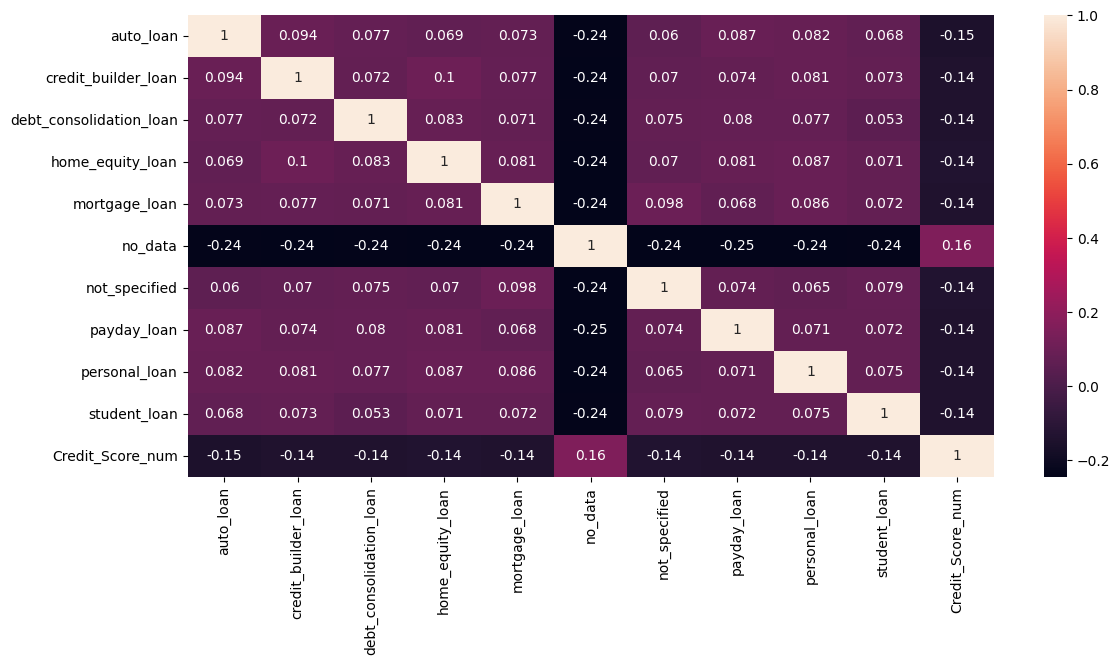

In [147]:
# probably the mhe(multi hot encoded) columns .. (ie: type_of_loan ) will have similar corr like ohe colmns ... lets see
plt.figure(figsize=(13,6))
sns.heatmap(df9[['auto_loan', 'credit_builder_loan',
       'debt_consolidation_loan', 'home_equity_loan', 'mortgage_loan',
       'no_data', 'not_specified', 'payday_loan', 'personal_loan',
       'student_loan','Credit_Score_num']].corr(), annot=True)


In [148]:
# the mhe cols corr with target is pretty good than ohe cols 
# because it also is less sparse than ohe cols as in mhe ... 1 row can multiple 'true' (1) amoung the all mhe  cols 
# where as in ohe cols ... only one amoung all ohe cols will have true(1) others are all false(0) which make the model sparse when combaining all those ohe cols


In [149]:
# so now that we saw the corr of each features and decided which to keep and remove ...
# well now deal with the outliers 
# to see the outliers lets 1st see the skewness of each feature .. that'll help us find feeatures with uneven distribution 
# then we can narrow down features that has more outliers

In [150]:
for col in df9.columns:
    print("{:<25s} : {}".format(col, df9[col].skew()))

Age                       : 0.15626247670755583
Annual_Income             : 1.1305160035181485
Num_Bank_Accounts         : -0.040678898624065866
Num_Credit_Card           : 0.22769681440231265
Interest_Rate             : 0.49616950326042203
Num_of_Loan               : 0.44560189031702674
Delay_from_due_date       : 0.9339252327052501
Num_of_Delayed_Payment    : -0.21472246022051872
Changed_Credit_Limit      : 0.708215693664281
Num_Credit_Inquiries      : 0.5058278160810435
Outstanding_Debt          : 1.2074424333567937
Credit_Utilization_Ratio  : 0.028654637744459158
Credit_History_Age        : -0.04864580722055706
Total_EMI_per_month       : 3.8653349837830087
Amount_invested_monthly   : 1.7612547875153852
Monthly_Balance           : 1.3558383098288296
Credit_Mix_num            : -0.10327549544782409
Payment_of_Min_Amount_num : -0.33579764302066833
Credit_Score_num          : 0.1380010835297919
Occupation_Architect      : 3.424282518746336
Occupation_Developer      : 3.457062281095279

In [151]:
# so apparently we no need to check ohe mhe and other catogorical cols .. since its CATOGORICAL 
# like we can't remove a whole catogory unless it that catogory conttains very low num of rows 
# even so if it has low rows .. it still usefull for finding patterns ... so we no need to analyse outliers for those 

In [152]:
cols_for_outlier_analysis = ['Age', 'Annual_Income', 'Num_Bank_Accounts', 'Num_Credit_Card',
       'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly',
       'Monthly_Balance']

In [153]:
skew_dict = {col: df9[col].skew() for col in df9[cols_for_outlier_analysis]}
sorted_skew = dict(sorted(skew_dict.items(), key=lambda x: x[1], reverse=True))

for k, v in sorted_skew.items():
    print(f"{k}: {v}")


Total_EMI_per_month: 3.8653349837830087
Amount_invested_monthly: 1.7612547875153852
Monthly_Balance: 1.3558383098288296
Outstanding_Debt: 1.2074424333567937
Annual_Income: 1.1305160035181485
Delay_from_due_date: 0.9339252327052501
Changed_Credit_Limit: 0.708215693664281
Num_Credit_Inquiries: 0.5058278160810435
Interest_Rate: 0.49616950326042203
Num_of_Loan: 0.44560189031702674
Num_Credit_Card: 0.22769681440231265
Age: 0.15626247670755583
Credit_Utilization_Ratio: 0.028654637744459158
Num_Bank_Accounts: -0.040678898624065866
Credit_History_Age: -0.04864580722055706
Num_of_Delayed_Payment: -0.21472246022051872


In [154]:
# if skewness is less than 0.5 its consider safe ... mostly 
# so we'll focus on finding outliers in the features where skewness is abouve 0.5 (or below -0.5)

<Axes: xlabel='Total_EMI_per_month', ylabel='Count'>

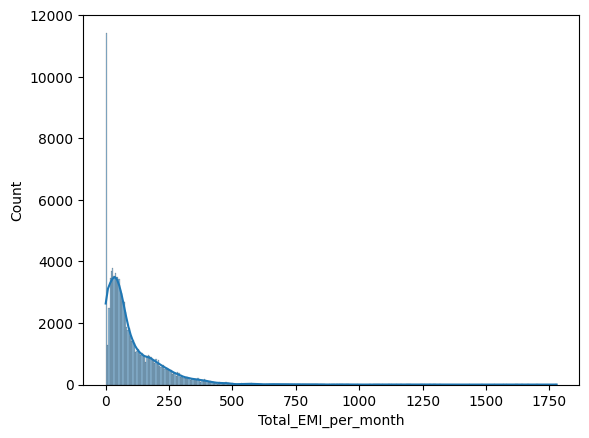

In [155]:
sns.histplot(df9.Total_EMI_per_month,kde=True)

In [156]:
df9[df9.Total_EMI_per_month > 500].shape

(1181, 44)

In [157]:
df9[['Total_EMI_per_month']].sort_values(by='Total_EMI_per_month',ascending=False).head(50)

,Total_EMI_per_month
35477,1779.103254
35476,1779.103254
35475,1779.103254
35478,1779.103254
35479,1779.103254
43790,1762.000000
71331,1745.000000
95626,1724.000000
84901,1702.000000
45357,1701.955013


In [158]:
# this feature dosent seem like it has outliers .... just some values with less count ... low data for Total_EMI_per_month > 500
# we can transform it .. scale it later 

<Axes: xlabel='Amount_invested_monthly', ylabel='Count'>

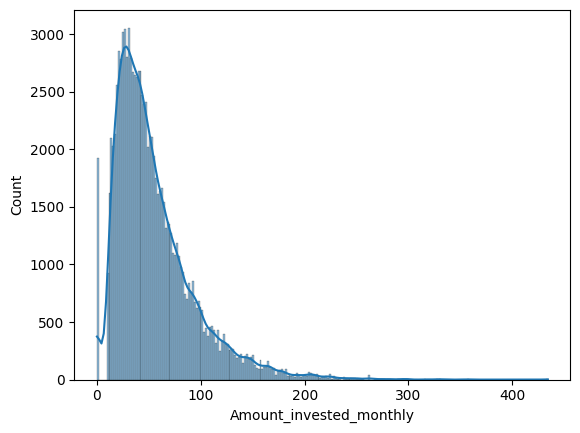

In [159]:
sns.histplot(df9.Amount_invested_monthly,kde=True)

In [160]:
df9[df9.Amount_invested_monthly > 300].shape

(40, 44)

In [161]:
df9.Amount_invested_monthly.describe()


count    99986.000000
mean        55.098971
std         39.007795
min          0.000000
25%         27.954834
50%         45.156261
75%         71.288876
max        434.191089
Name: Amount_invested_monthly, dtype: float64

In [162]:
df9[num_cols_with_0].sort_values(by='Amount_invested_monthly',ascending=False).head(30)

,Num_Bank_Accounts,Num_Credit_Card,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Num_Credit_Inquiries,Total_EMI_per_month,Amount_invested_monthly
16737,7.0,5.0,2.0,13.0,12.0,5.798682,187.464323,434.191089
16739,7.0,5.0,2.0,16.0,12.0,5.798682,187.464323,434.191089
16736,7.0,5.0,2.0,13.0,12.0,5.798682,187.464323,434.191089
16738,7.0,5.0,2.0,13.0,12.0,5.798682,187.464323,434.191089
16743,7.0,5.0,2.0,13.0,15.0,5.798682,187.464323,434.191089
16742,7.0,5.0,2.0,14.0,12.0,5.798682,187.464323,434.191089
16741,7.0,5.0,2.0,16.0,12.0,5.798682,187.464323,434.191089
16740,7.0,5.0,2.0,15.0,12.0,5.798682,187.464323,434.191089
98932,3.0,5.0,0.0,9.0,6.0,5.000000,0.000000,356.550361
98931,3.0,5.0,0.0,12.0,5.0,5.000000,0.000000,356.550361


In [163]:
# it dosent look like outlier .. may be we can cap it 
# or may be drop it since im not sure if it is an outlier or not 
# also .. even if its not outlier .. it still is a extreme value ..
# also its just 40 rows

In [164]:
df10 = df9[df9.Amount_invested_monthly < 301]
df10.shape

(99946, 44)

<Axes: xlabel='Monthly_Balance', ylabel='Count'>

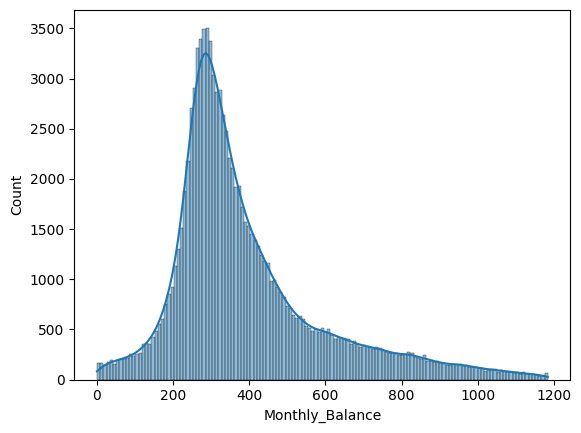

In [165]:
# next Monthly_Balance

sns.histplot(df10.Monthly_Balance, kde=True)

In [166]:
df10.Monthly_Balance.describe()

count    99946.000000
mean       392.590051
std        201.542789
min          0.007760
25%        267.604774
50%        333.813827
75%        462.962679
max       1183.930696
Name: Monthly_Balance, dtype: float64

In [167]:
df10[df10.Monthly_Balance > 1150 ].shape

(194, 44)

In [168]:
# this seems like its just slightly noisy ... actually pretty good 
# so no removiing ... we'll scale it later

<Axes: xlabel='Outstanding_Debt', ylabel='Count'>

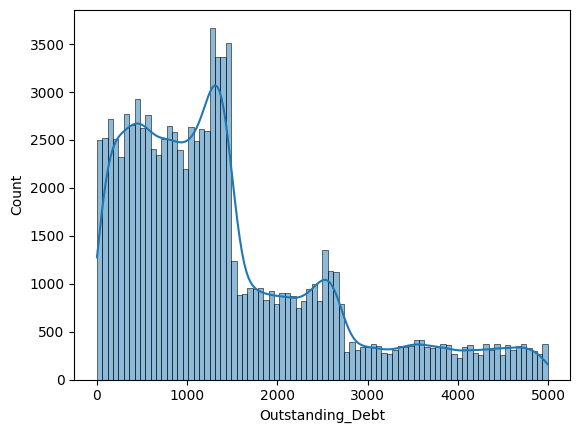

In [169]:
# next Outstanding_Debt

sns.histplot(df10.Outstanding_Debt, kde=True)

In [170]:
# this clearly is not outliers ... well scale it later

<Axes: xlabel='Annual_Income', ylabel='Count'>

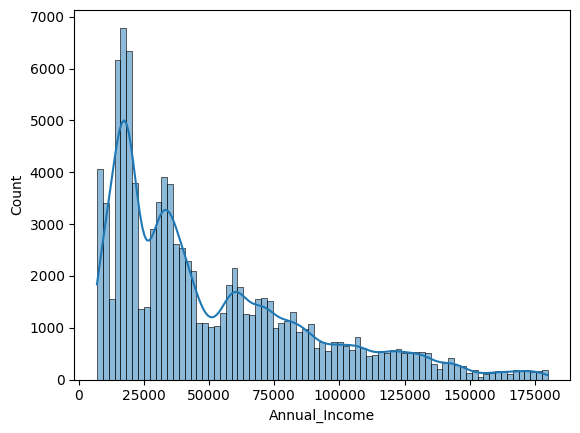

In [171]:
# next Annual_Income

sns.histplot(df10.Annual_Income, kde=True)

In [172]:
df10[df10.Annual_Income > 174000].shape

(432, 44)

In [173]:
# okay ... we'll scale this as well .. nothing to remove

<Axes: xlabel='Delay_from_due_date', ylabel='Count'>

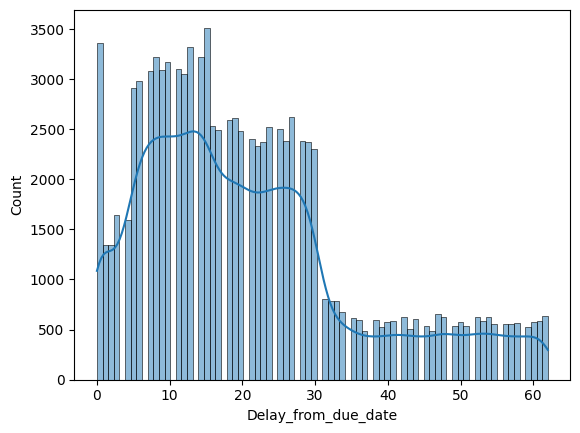

In [174]:
# next Delay_from_due_date

sns.histplot(df10.Delay_from_due_date, kde=True)

In [175]:
# scale it 

<Axes: xlabel='Changed_Credit_Limit', ylabel='Count'>

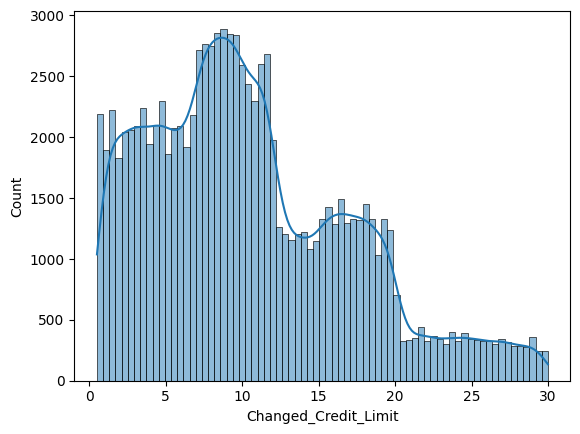

In [176]:
# next Changed_Credit_Limit

sns.histplot(df10.Changed_Credit_Limit, kde=True)

In [177]:
df10[df10.Changed_Credit_Limit > 29.7].shape

(204, 44)

In [178]:
# scale it

<Axes: xlabel='Num_Credit_Inquiries', ylabel='Count'>

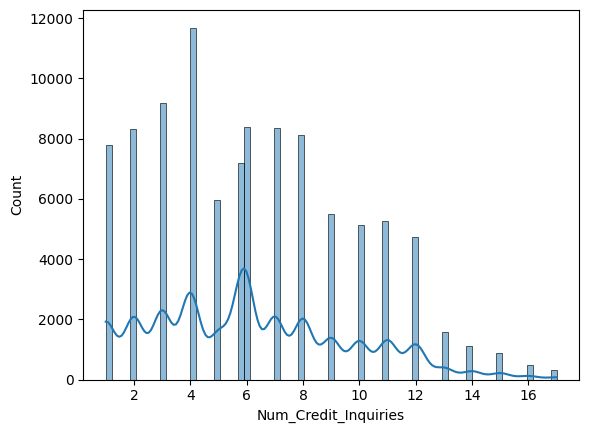

In [179]:
# next Num_Credit_Inquiries

sns.histplot(df10.Num_Credit_Inquiries, kde=True)

In [180]:
df10[df10.Num_Credit_Inquiries > 16].shape

(304, 44)

In [181]:
# scale ... 

<Axes: xlabel='Num_of_Delayed_Payment', ylabel='Count'>

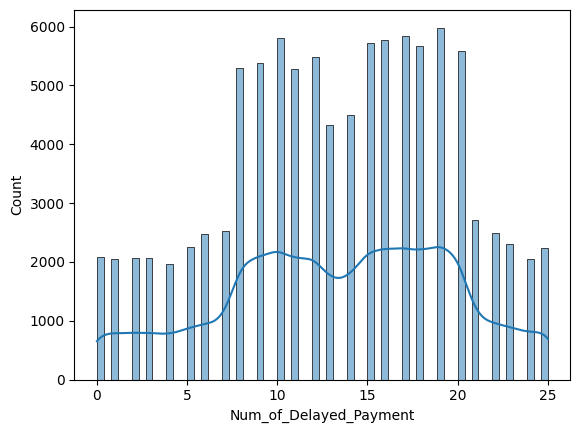

In [182]:
# next Num_of_Delayed_Payment
sns.histplot(df10.Num_of_Delayed_Payment, kde=True)

In [183]:
# scale it ....

In [184]:
# after this other have less than 0.5 skew 
# but still for safty well see their distribution and do a quick analysis together

<Axes: xlabel='Num_of_Delayed_Payment', ylabel='Count'>

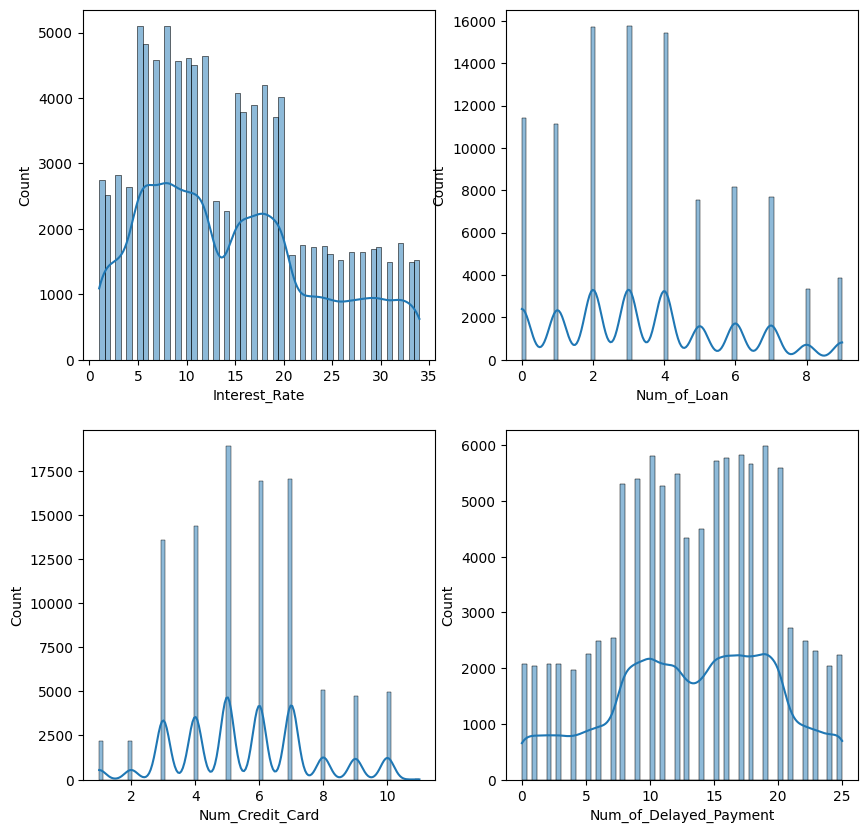

In [185]:
fig,axes = plt.subplots(2,2,figsize=(10,10))

sns.histplot(df10.Interest_Rate , kde=True ,ax=axes[0,0])
sns.histplot(df10.Num_of_Loan , kde=True ,ax=axes[0,1])
sns.histplot(df10.Num_Credit_Card , kde=True ,ax=axes[1,0])
sns.histplot(df10.Num_of_Delayed_Payment , kde=True ,ax=axes[1,1])


# other 3 features have less than 0.1 so no need to bother those

In [186]:
# okay so no outliers ... 

In [187]:
# so now that we checked outliers ... we can now move ahead and scale the features so that it dosent the skewness becomes less

In [188]:
skew_dict = {col: df10[col].skew() for col in df10[cols_for_outlier_analysis]}
sorted_skew = dict(sorted(skew_dict.items(), key=lambda x: x[1], reverse=True))

for k, v in sorted_skew.items():
    print(f"{k}: {v}")


Total_EMI_per_month: 3.869952554560445
Amount_invested_monthly: 1.6383581642205194
Monthly_Balance: 1.3562817332725257
Outstanding_Debt: 1.206961076422802
Annual_Income: 1.1300010064120751
Delay_from_due_date: 0.9336254907327092
Changed_Credit_Limit: 0.7080959265309762
Num_Credit_Inquiries: 0.5054881518048958
Interest_Rate: 0.49569771518921396
Num_of_Loan: 0.4455530485963204
Num_Credit_Card: 0.22735189891383845
Age: 0.1569020055153086
Credit_Utilization_Ratio: 0.028788406081642067
Num_Bank_Accounts: -0.04109687148395771
Credit_History_Age: -0.04828650809814749
Num_of_Delayed_Payment: -0.21532909688006452


In [189]:
# since Total_EMI_per_month's skew is greater than 0.3 .. it needs powerfull transformation .. like log transform
# but for others since its around 1 we can use simple transformation

In [190]:
df11 = df10.copy()

In [191]:
# df11.Total_EMI_per_month = np.log1p(df11.Total_EMI_per_month)

In [192]:
# Num_Credit_Inquiries also has high skew around -2 .. so log for that as well

df11.Num_Credit_Inquiries = np.log1p(df11.Num_Credit_Inquiries)

In [193]:
from sklearn.preprocessing import PowerTransformer,StandardScaler

modrate_skew_cols = ['Total_EMI_per_month','Amount_invested_monthly','Monthly_Balance','Outstanding_Debt',\
                     'Annual_Income','Delay_from_due_date','Changed_Credit_Limit',\
                     'Num_Credit_Inquiries']

pt = PowerTransformer(method='yeo-johnson')

df11[modrate_skew_cols] = pt.fit_transform(df11[modrate_skew_cols])

In [194]:
skew_dict = {col: df11[col].skew() for col in df11[cols_for_outlier_analysis]}
sorted_skew = dict(sorted(skew_dict.items(), key=lambda x: x[1], reverse=True))

for k, v in sorted_skew.items():
    print(f"{k}: {v}")


Interest_Rate: 0.49569771518921396
Num_of_Loan: 0.4455530485963204
Num_Credit_Card: 0.22735189891383845
Age: 0.1569020055153086
Monthly_Balance: 0.12526763140942307
Amount_invested_monthly: 0.08758712213293966
Credit_Utilization_Ratio: 0.028788406081642067
Annual_Income: -0.012145574318230292
Num_Bank_Accounts: -0.04109687148395771
Outstanding_Debt: -0.04418655809946969
Delay_from_due_date: -0.04532380180341218
Credit_History_Age: -0.04828650809814749
Total_EMI_per_month: -0.05586090922008753
Changed_Credit_Limit: -0.058086819683672006
Num_Credit_Inquiries: -0.12294900005139534
Num_of_Delayed_Payment: -0.21532909688006452


In [195]:
# so basicaly log transform is only usefull is the skew is soo big ... and it cannot handle zero or negative values .. etc..
# so i tried log for Total_EMI_per_month it still was slightly skewed 
# so i tried agin with jeo johnson itself .. which can handle all negative possitive and zero values perfectly .. 
# and for not so big skew like 3.8 it worked fine 


In [196]:
# not lets scale the featuresv 
# except ohe and mhe cols as its just 0 or 1 .. scaling makes it useless ..kinda
# scaling ohe and mhe actually is meaningless as its already in the range of 0-1 (more like 0 OR 1)

# also dont scale target ... credit_score_num

In [197]:
df12 = df11.copy()

In [198]:
scale_cols = ['Age', 'Annual_Income', 'Num_Bank_Accounts', 'Num_Credit_Card',
       'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly',
       'Monthly_Balance', 'Credit_Mix_num', 'Payment_of_Min_Amount_num', 'Payment_Behaviour_num']

st_scaler = StandardScaler()

df12[scale_cols] = st_scaler.fit_transform(df12[scale_cols])

df12[scale_cols].describe()

,Age,Annual_Income,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_Mix_num,Payment_of_Min_Amount_num,Payment_Behaviour_num
count,9.994600e+04,9.994600e+04,9.994600e+04,9.994600e+04,9.994600e+04,9.994600e+04,9.994600e+04,9.994600e+04,9.994600e+04,9.994600e+04,9.994600e+04,9.994600e+04,9.994600e+04,9.994600e+04,9.994600e+04,9.994600e+04,9.994600e+04,9.994600e+04,9.994600e+04
mean,2.292027e-16,1.706224e-17,6.022970e-16,1.841300e-16,2.047469e-17,-8.872364e-17,-2.616210e-17,-7.535822e-18,-7.962378e-18,-2.559336e-17,2.530899e-17,4.731928e-16,3.981189e-17,1.933720e-17,-2.729958e-17,-2.317621e-17,-8.047690e-17,-8.559557e-17,-1.018047e-16
std,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00
min,-1.794128e+00,-2.062391e+00,-1.988554e+00,-2.194477e+00,-1.548306e+00,-1.444187e+00,-2.236750e+00,-2.135122e+00,-2.154841e+00,-1.851754e+00,-2.852067e+00,-2.400827e+00,-2.208866e+00,-1.873839e+00,-2.966046e+00,-4.806893e+00,-1.454316e+00,-1.264318e+00,-1.445456e+00
25%,-8.650826e-01,-8.492443e-01,-6.967071e-01,-7.426932e-01,-8.619639e-01,-6.267213e-01,-6.356835e-01,-6.920798e-01,-6.972246e-01,-8.989765e-01,-6.685616e-01,-8.271283e-01,-7.742366e-01,-5.584899e-01,-6.671818e-01,-5.649972e-01,-8.990842e-02,-1.264318e+00,-8.000419e-01
50%,-2.894146e-02,-4.167775e-02,-4.365080e-04,-2.587653e-01,-1.756222e-01,-2.179886e-01,1.341394e-02,1.096101e-01,1.850134e-02,4.627193e-02,4.061129e-02,3.891724e-03,-2.180842e-02,1.684490e-03,-6.646564e-02,-1.599100e-01,-8.990842e-02,9.024274e-01,-1.546279e-01
75%,8.071996e-01,8.084394e-01,5.951395e-01,7.090905e-01,6.251099e-01,5.994768e-01,6.278325e-01,7.509620e-01,7.585585e-01,6.217124e-01,6.643693e-01,8.231394e-01,8.108787e-01,6.860203e-01,6.141335e-01,5.022575e-01,1.274499e+00,9.024274e-01,1.136200e+00
max,2.107864e+00,2.041051e+00,2.317602e+00,2.644802e+00,2.226574e+00,2.234408e+00,2.080443e+00,1.873328e+00,2.225356e+00,2.267603e+00,2.146063e+00,3.462363e+00,1.834181e+00,4.280169e+00,3.681409e+00,2.903091e+00,1.274499e+00,9.024274e-01,1.781614e+00


In [199]:
df12.Credit_Score_num.describe()

count    99946.000000
mean         0.888110
std          0.675047
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          2.000000
Name: Credit_Score_num, dtype: float64

In [200]:
df12.Credit_Score_num.value_counts()

Credit_Score_num
1    53151
0    28989
2    17806
Name: count, dtype: int64

In [201]:
# df12.to_csv('ready_to_model_dataset.csv',index=False)

In [202]:
df12.columns

Index(['Age', 'Annual_Income', 'Num_Bank_Accounts', 'Num_Credit_Card',
       'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly',
       'Monthly_Balance', 'Credit_Mix_num', 'Payment_of_Min_Amount_num',
       'Credit_Score_num', 'Occupation_Architect', 'Occupation_Developer',
       'Occupation_Doctor', 'Occupation_Engineer', 'Occupation_Entrepreneur',
       'Occupation_Journalist', 'Occupation_Lawyer', 'Occupation_Manager',
       'Occupation_Mechanic', 'Occupation_Media_Manager',
       'Occupation_Musician', 'Occupation_Scientist', 'Occupation_Teacher',
       'Occupation_Writer', 'auto_loan', 'credit_builder_loan',
       'debt_consolidation_loan', 'home_equity_loan', 'mortgage_loan',
       'no_data', 'not_specified', 'payday_loan', 'personal_loan',
       'student

In [203]:
df_final = df12.copy()

In [204]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(criterion='entropy',n_estimators=130,class_weight='balanced')

In [205]:
df_final.shape

(99946, 44)

In [206]:
X = df_final.drop('Credit_Score_num',axis='columns')
X.shape

(99946, 43)

In [207]:
y = df_final.Credit_Score_num
y

0        2
1        2
2        2
3        2
4        2
        ..
99995    0
99996    0
99997    0
99998    1
99999    0
Name: Credit_Score_num, Length: 99946, dtype: int64

In [208]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=21, stratify=df_final.Credit_Score_num)

In [209]:
print(xtrain.shape,ytrain.shape,xtest.shape,ytest.shape)

(79956, 43) (79956,) (19990, 43) (19990,)


In [210]:
model_rf.fit(xtrain,ytrain)

,n_estimators,130
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [211]:
model_rf.score(xtest,ytest)

0.8183091545772886